In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [36]:
def cost_fn(w,b,x,y):
    fn=np.dot(x,w)+b
    m=x.shape[0]
    cost=(1/(2*m))*np.sum((fn-y)**2)
    return cost

In [37]:
def derivative(w,b,x,y):
    fn=np.dot(x,w)+b
    err=fn-y
    m=x.shape[0]
    dw=(1/m)*(np.dot(x.T,err))
    db=(1/m)*(np.sum(err))
    return dw,db

In [38]:
def gradient_descent(w,b,x,y,alpha,derivative,cost_fn,iteration):
    history=[]
    for i in range(iteration):
        dw,db=derivative(w,b,x,y)
        w=w-alpha*dw
        b=b-alpha*db
        history.append(cost_fn(w,b,x,y))
        if(cost_fn(w,b,x,y)<0.001):
            break
    return w,b,history

In [183]:
def Z_score(x):
    mu=np.mean(x,axis=0)
    sigma=np.std(x,axis=0)
    sigma[sigma==0]=1
    Z=(x-mu)/sigma
    return Z

w = [553571.40650177 100258.60734744 466118.06503754 374344.99468833
 125103.36137867 111680.37919254 161155.57269228 197956.71073671
 380124.17585879 220734.84752425 290253.04867683 140490.78445634]
b = 4713728.876085304


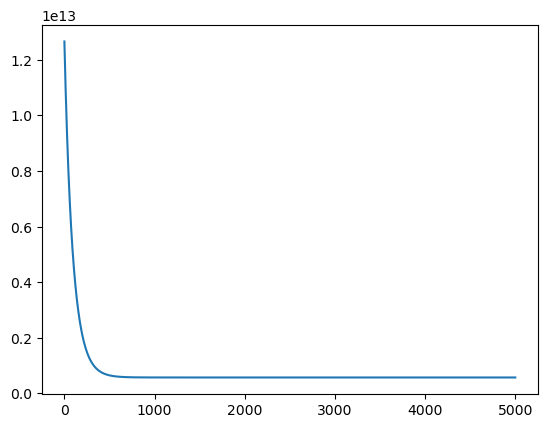

In [232]:
house=pd.read_csv("Housing.csv")
cols=["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea"]
for col in cols:
    house[col]=house[col].map({
        "yes":1,
        "no":0
    })
house["furnishingstatus"]=house["furnishingstatus"].map({
    "furnished":1,
    "semi-furnished":0.5,
    "unfurnished":0
})
x=np.array(house[["area","bedrooms","bathrooms","stories","mainroad","guestroom","basement","hotwaterheating","airconditioning","parking","prefarea","furnishingstatus"]])
y=np.array(house["price"])

#randomizing the dataset order
np.random.seed(1252)
indices=np.random.permutation(len(x))
x=x[indices]
y=y[indices]

#80% training and 20% testing
split=int(0.8*len(x))
x_train=x[:split]
y_train=y[:split]
x_test=x[split:]
y_test=y[split:]
x_train=Z_score(x_train)
w=np.zeros((x_train.shape[1],))
b=0
alpha=0.005
iteration=5000
w,b,history=gradient_descent(w,b,x_train,y_train,alpha,derivative,cost_fn,iteration)
plt.plot(range(len(history)),history)
print(f"w = {w}\nb = {b}")

In [233]:
x_test=Z_score(x_test)
y_pred=np.dot(x_test,w)+b
#Mean Square Error
mse=np.mean((y_pred-y_test)**2)
print(f"MSE = {mse}")
#root mean Squre Error
rmse = np.sqrt(mse)
print(f"RMSE = {rmse}")
#R^2 test
ss_total=np.sum((y_test-np.mean(y_test))**2)
ss_residual=np.sum((y_test-y_pred)**2)
r2=1-(ss_residual/ss_total)
print(f"R^2 test = {r2}")

MSE = 1137261259157.171
RMSE = 1066424.5210783419
R^2 test = 0.7081644744623048
